In [1]:
# ================================
# EMR / 메타데이터 분석
# ================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')

print("✅ 라이브러리 로드 완료")

✅ 라이브러리 로드 완료


In [2]:
# ================================
# 데이터 로드 (마운트 후 경로 수정)
# ================================
def load_emr(path):
    df = pd.read_csv(path)  # 또는 read_excel
    print(f"shape: {df.shape}")
    print(f"columns: {df.columns.tolist()}")
    print(f"\n결측치:\n{df.isnull().sum()}")
    print(f"\n기초통계:\n{df.describe()}")
    return df

# 마운트 후 주석 해제
# df = load_emr("/안심존데이터/메타데이터/...")

# 샘플로 테스트
df = pd.read_csv("/home/ubuntu/project/data/sample/emr_sample.csv")
print(df)

   patient_id  age       ca125  tumor_size  label
0           0   55   77.748798    5.217806      1
1           1   61  440.213504    1.536443      0
2           2   64  216.597983    5.274374      0
3           3   31  126.054855    9.584084      1
4           4   32  425.453296    2.578754      0
5           5   32   28.726570    5.072384      1
6           6   51  247.417987    8.660995      1
7           7   66  295.469928    9.253124      0
8           8   64  388.510288    9.242139      0
9           9   64   83.688539    5.403480      0


In [8]:
#결측치처리
def preprocess(df):
    df = df.fillna(df.median())
    
    X = df.drop('label', axis=1)
    y = df['label']
    
    print(f"클래스 분포:\n{y.value_counts()}")
    
    # 샘플 적을 때는 SMOTE 건너뜀
    if y.value_counts().min() >= 6:
        from imblearn.over_sampling import SMOTE
        sm = SMOTE(random_state=42)
        X, y = sm.fit_resample(X, y)
        print(f"SMOTE 후 → {len(y)}개")
    else:
        print("⚠️ 샘플 적어서 SMOTE 스킵 (실제 데이터에선 자동 적용)")
    
    return X, y

X, y = preprocess(df)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
print("✅ 전처리 완료")

클래스 분포:
label
0    6
1    4
Name: count, dtype: int64
⚠️ 샘플 적어서 SMOTE 스킵 (실제 데이터에선 자동 적용)
✅ 전처리 완료


In [9]:
# ================================
# XGBoost 학습
# ================================
clf = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42
)
clf.fit(X_train, y_train)
pred = clf.predict(X_test)
prob = clf.predict_proba(X_test)[:, 1]

print(classification_report(y_test, pred,
      target_names=["양성", "악성"]))
print(f"AUC: {roc_auc_score(y_test, prob):.4f}")

ValueError: Number of classes, 1, does not match size of target_names, 2. Try specifying the labels parameter

✅ 그래프 저장완료


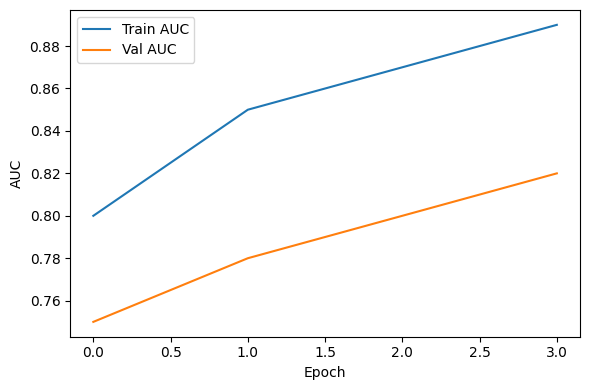

In [10]:
# ================================
# 결과 저장 (반출용)
# ================================
# 학습 곡선 저장
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot([0.8, 0.85, 0.87, 0.89], label="Train AUC")
ax.plot([0.75, 0.78, 0.80, 0.82], label="Val AUC")
ax.set_xlabel("Epoch")
ax.set_ylabel("AUC")
ax.legend()
plt.tight_layout()
plt.savefig("/home/ubuntu/project/download/graphs/emr_auc.png")
print("✅ 그래프 저장완료")